In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ACTIVATIONS_ROOT = './activations/'
DATASET_ROOT = './datasets'
RESULTS_DIR = './results'

label_fontsize = 18

In [2]:
import torch

use_cuda = torch.cuda.is_available()
use_mps = torch.backends.mps.is_available() and False

if use_cuda:
    device = torch.device("cuda")
elif use_mps:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [3]:
from src.spectral_cka import predict_cka

In [4]:
def random_orthonormal(P):
    """
    Returns a random PxP orthonormal matrix via QR-decomposition.
    """
    H = np.random.randn(P, P)
    Q, _ = np.linalg.qr(H)
    return Q


def cka(G1, G2):
    """
    Linear HSIC-normalized CKA between two Gram matrices.
    """
    num = np.trace(G1 @ G2)
    den = np.linalg.norm(G1, 'fro') * np.linalg.norm(G2, 'fro')
    return num / den


def make_powerlaw_grams(P, alpha, cka_target, tol=1e-3, max_iter=30):

    from scipy.linalg import logm, expm

    """
    Build two PxP Gram matrices G1 and G2 with identical eigenvalues ~ i^alpha,
    but whose CKA(G1,G2) ≈ cka_target in [0,1].
    """
    # 1) spectrum
    vals = np.arange(1, P+1) ** alpha
    D = np.diag(vals)

    # 2) two random bases
    Q1 = random_orthonormal(P)
    Qrand = random_orthonormal(P)

    # 3) form G1
    G1 = Q1 @ D @ Q1.T
    norm1 = np.linalg.norm(G1, 'fro')

    # 4) compute relative rotation M ∈ O(P)
    M = Qrand @ Q1.T
    # ensure det(M)=+1 (so logm is real skew-symmetric)
    if np.linalg.det(M) < 0:
        Qrand[:, 0] *= -1
        M = Qrand @ Q1.T

    # 5) Lie‐algebra element A = logm(M) (skew‐symmetric)
    A = logm(M)

    # 6) helper: at time t build G2(t) and its CKA
    def G2_and_cka(t):
        Mt = expm(t * A)          # geodesic: exp(t log(M))
        Q2 = Mt @ Q1
        G2 = Q2 @ D @ Q2.T
        return G2, np.trace(G1 @ G2) / (norm1 * np.linalg.norm(G2, 'fro'))

    # 7) binary‐search for t ∈ [0,1]
    lo, hi = 0.0, 1.0
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        _, c = G2_and_cka(mid)
        if abs(c - cka_target) < tol:
            break
        if c > cka_target:
            lo = mid
        else:
            hi = mid

    G2, final_cka = G2_and_cka(mid)
    print(f"Reached CKA = {final_cka:.4f} at t = {mid:.4f}")
    return G1, G2


def matrix_sqrt_eig(A):
    """Compute matrix square root using eigendecomposition."""
    # Ensure A is symmetric
    A = (A + A.T) / 2
    eigvals, eigvecs = torch.linalg.eigh(A)
    sqrt_eigvals = torch.sqrt(torch.clamp(eigvals, min=0))
    sqrt_A = eigvecs @ torch.diag(sqrt_eigvals) @ eigvecs.T
    sqrt_A = sqrt_A.to(torch.float64)
    return sqrt_A

### Figure 2 - CKA and CCA between misaligned synthetic data with same power law spectrum


In [5]:
P = 500  # 100
neuron_sizes = [10,  22,  35,  48,  61,  74,  87, 100, 150, 200]
cutoff = None
num_iterations = 20

alpha = -1.2
target_cka = 0.5

filename = RESULTS_DIR + f"/cka_cca_target_cka_{target_cka}_alpha_{alpha}_P_{P}.npz"

In [6]:
# Run the analysis
if not os.path.exists(filename):
    # G1 and G2 now share eigenvalues (i^alpha) but have CKA ≈ 0.5
    pop_gram1, pop_gram2 = make_powerlaw_grams(P, alpha, target_cka)

    # Convert to torch tensors
    pop_gram1_tensor = torch.tensor(pop_gram1, dtype=torch.float64).to(device)
    pop_gram2_tensor = torch.tensor(pop_gram2, dtype=torch.float64).to(device)

    # Take square root using matrix_sqrt_eig (since these are diagonal matrices, simple sqrt would work too)
    act1 = matrix_sqrt_eig(pop_gram1_tensor)
    act2 = matrix_sqrt_eig(pop_gram2_tensor)

    results = predict_cka(act1, act2, neuron_sizes, cutoff=cutoff, num_iterations=num_iterations)
    np.savez(filename, results=results, neuron_sizes=neuron_sizes)
else:
    data = np.load(filename, allow_pickle=True)
    results = data['results'].item()
    neuron_sizes = data['neuron_sizes']

naive_mean_cka = np.asarray(results['cka_naive_mean'])
naive_std_cka = np.asarray(results['cka_naive_std'])
predicted_cka = np.asarray(results['predicted_cka_final'])
est_mean_cka = np.asarray(results['estimated_cka_final'])
est_std_cka = np.asarray(results['cka_est_std'])
est_sem_cka = est_std_cka / np.sqrt(num_iterations)

# Convert lists to numpy arrays for CCA
naive_mean_cca = np.asarray(results['cca_naive_mean'])
naive_std_cca = np.asarray(results['cca_naive_std'])
predicted_cca = np.asarray(results['predicted_cca_final'])
est_mean_cca = np.asarray(results['estimated_cca_final'])
est_std_cca = np.asarray(results['cca_est_std'])
est_sem_cca = est_std_cca / np.sqrt(num_iterations)

moment_cka_est_mean = np.asarray(results['moment_cka_est_mean'])
moment_cka_est_std = np.asarray(results['moment_cka_est_std'])
moment_cka_est_sem = moment_cka_est_std / np.sqrt(num_iterations)

true_cka = results['true_cka']
true_cca = results['true_cca']
print(f"True CKA: {true_cka}, True CCA: {true_cca}")

True CKA: 0.499980497218841, True CCA: 0.5002718245690668


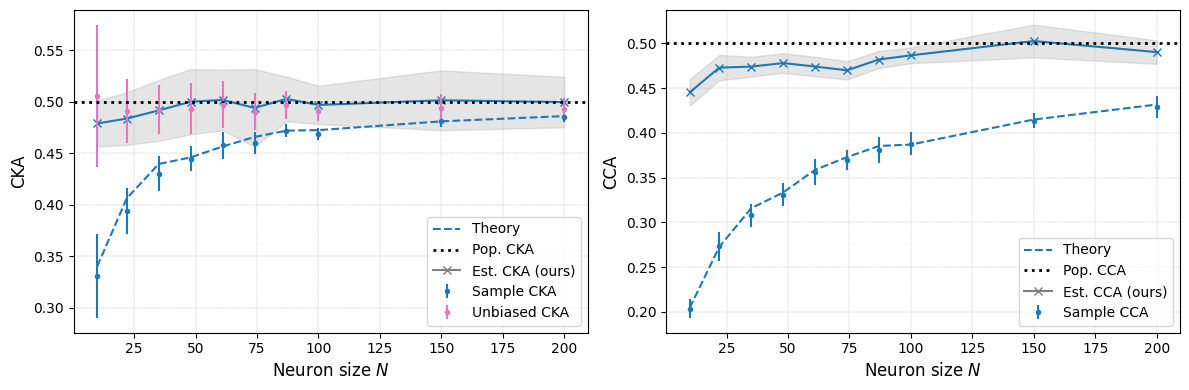

In [7]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# First subplot for CKA
ax1.errorbar(neuron_sizes, naive_mean_cka, naive_std_cka,
             fmt='.', color='C0', label='Sample CKA')
ax1.plot(neuron_sizes, predicted_cka, linestyle='--', color='C0', label='Theory')

ax1.plot(neuron_sizes, est_mean_cka, 'x-', color='C0')
ax1.fill_between(neuron_sizes,
                 est_mean_cka - est_sem_cka,
                 est_mean_cka + est_sem_cka,
                 color='gray', alpha=0.2)

ax1.errorbar(neuron_sizes, moment_cka_est_mean[:, -1], moment_cka_est_sem[:, -1],
             fmt='.', color='C6', label='Unbiased CKA')

ax1.axhline(y=true_cka, color='black', linestyle=':', linewidth=2, label='Pop. CKA')
ax1.plot([], 'x-', c='gray', label='Est. CKA (ours)')
ax1.set_xlabel(r"Neuron size $N$", fontsize=12)
ax1.set_ylabel(r"CKA", fontsize=12)
ax1.grid(True, which='both', linestyle='--', linewidth=0.3)
# ax1.set_xlim([neuron_sizes[0]-1, neuron_sizes[-1]])
ax1.legend(loc='lower right', fontsize=10)

# Second subplot for CCA
ax2.errorbar(neuron_sizes, naive_mean_cca, naive_std_cca, fmt='.', color='C0', label='Sample CCA')
ax2.plot(neuron_sizes, predicted_cca, linestyle='--', color='C0', label='Theory')

ax2.plot(neuron_sizes, est_mean_cca, 'x-', color='C0')
ax2.fill_between(neuron_sizes,
                 est_mean_cca - est_sem_cca,
                 est_mean_cca + est_sem_cca,
                 color='gray', alpha=0.2)

ax2.axhline(y=true_cca, color='black', linestyle=':', linewidth=2, label='Pop. CCA')
ax2.plot([], 'x-', c='gray', label='Est. CCA (ours)')
ax2.set_xlabel(r"Neuron size $N$", fontsize=12)
ax2.set_ylabel(r"CCA", fontsize=12)
ax2.grid(True, which='both', linestyle='--', linewidth=0.3)
# ax2.set_xlim([neuron_sizes[0]-1, neuron_sizes[-1]])
ax2.legend(loc='lower right', fontsize=10)

plt.tight_layout()
# plt.savefig('figures/cka_cca_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

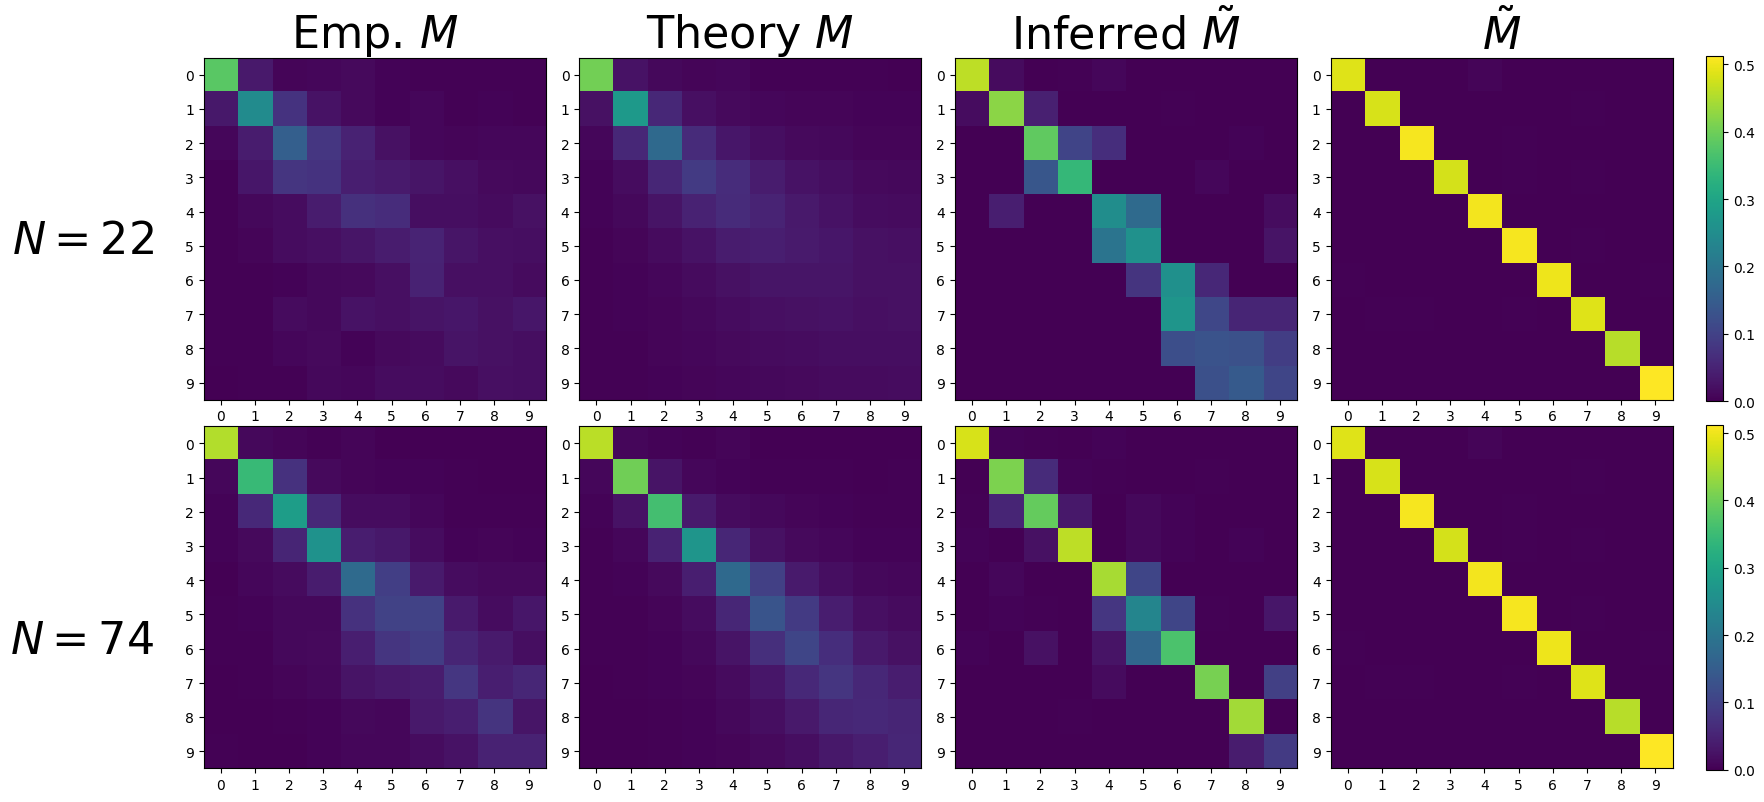

In [8]:
# Create one figure with two rows
fig = plt.figure(figsize=(16, 8))
gs = plt.GridSpec(2, 5, width_ratios=[1, 1, 1, 1, 0.05], height_ratios=[1, 1])

titles = ['Emp. $M$', 'Theory $M$', 'Inferred $\\tilde{M}$', '$\\tilde{M}$']
matrices_all = []

selected_N = [22, 74]

# First collect all matrices and find global min/max
for N in selected_N:
    i = np.where(np.array(neuron_sizes) == N)[0][0]

    M_avg = np.array(results['M_emp_mean'][i])[:10, :10]
    M_pred = np.array(results['M_pred_final'][i])[:10, :10]
    M_tilde_pred = np.array(results['M_tilde_pred_final'][i])[:10, :10]
    M_tilde = np.array(results['M_tilde'][i])[:10, :10]

    matrices = [M_avg, M_pred, M_tilde_pred, M_tilde]
    matrices_all.append(matrices)

# Find global min/max across all matrices
all_matrices = [m for row in matrices_all for sublist in row for m in [sublist]]
vmin = min(m.min() for m in all_matrices)
vmax = max(m.max() for m in all_matrices)

# Plot each row
for row, (N, matrices) in enumerate(zip(selected_N, matrices_all)):
    # Add N value on the left
    plt.figtext(-0.01, 0.7-row*0.5, f'$N={N}$', fontsize=32, ha='right', va='center')

    for col, (matrix, title) in enumerate(zip(matrices, titles)):
        ax = plt.subplot(gs[row, col])
        im = ax.imshow(matrix, cmap='viridis', vmin=vmin, vmax=vmax)
        if row == 0:  # Only show titles on top row
            ax.set_title(title, fontsize=32)
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))

    # Add colorbar for each row
    cax = plt.subplot(gs[row, -1])
    plt.colorbar(im, cax=cax)

plt.tight_layout()
# plt.savefig(os.path.join(save_path, 'M_tilde_M_comparison.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### Figure 2 - CKA and CCA between identical synthetic data


In [9]:
P = 500  # 100
neuron_sizes = [10,  22,  35,  48,  61,  74,  87, 100, 150, 200]
cutoff = None
num_iterations = 20

alpha = -1.2
target_cka = 1.0

filename = RESULTS_DIR + f"/cka_cca_target_cka_{target_cka}_alpha_{alpha}_P_{P}.npz"

In [10]:
# Run the analysis
if not os.path.exists(filename):
    # G1 and G2 now share eigenvalues and eigenvectors
    pop_gram1, pop_gram2 = make_powerlaw_grams(P, alpha, target_cka)

    # Convert to torch tensors
    pop_gram1_tensor = torch.tensor(pop_gram1, dtype=torch.float64).to(device)
    pop_gram2_tensor = torch.tensor(pop_gram2, dtype=torch.float64).to(device)

    # Take square root using matrix_sqrt_eig (since these are diagonal matrices, simple sqrt would work too)
    act1 = matrix_sqrt_eig(pop_gram1_tensor)
    act2 = matrix_sqrt_eig(pop_gram2_tensor)

    results = predict_cka(act1, act2, neuron_sizes, cutoff=cutoff, num_iterations=num_iterations)
    np.savez(filename, results=results, neuron_sizes=neuron_sizes)
else:
    data = np.load(filename, allow_pickle=True)
    results = data['results'].item()
    neuron_sizes = data['neuron_sizes']

naive_mean_cka = np.asarray(results['cka_naive_mean'])
naive_std_cka = np.asarray(results['cka_naive_std'])
predicted_cka = np.asarray(results['predicted_cka_final'])
est_mean_cka = np.asarray(results['estimated_cka_final'])
est_std_cka = np.asarray(results['cka_est_std'])
est_sem_cka = est_std_cka / np.sqrt(num_iterations)

# Convert lists to numpy arrays for CCA
naive_mean_cca = np.asarray(results['cca_naive_mean'])
naive_std_cca = np.asarray(results['cca_naive_std'])
predicted_cca = np.asarray(results['predicted_cca_final'])
est_mean_cca = np.asarray(results['estimated_cca_final'])
est_std_cca = np.asarray(results['cca_est_std'])
est_sem_cca = est_std_cca / np.sqrt(num_iterations)

moment_cka_est_mean = np.asarray(results['moment_cka_est_mean'])
moment_cka_est_std = np.asarray(results['moment_cka_est_std'])
moment_cka_est_sem = moment_cka_est_std / np.sqrt(num_iterations)

true_cka = results['true_cka']
true_cca = results['true_cca']
print(f"True CKA: {true_cka}, True CCA: {true_cca}")

True CKA: 0.9991814371921814, True CCA: 0.9992132273394824


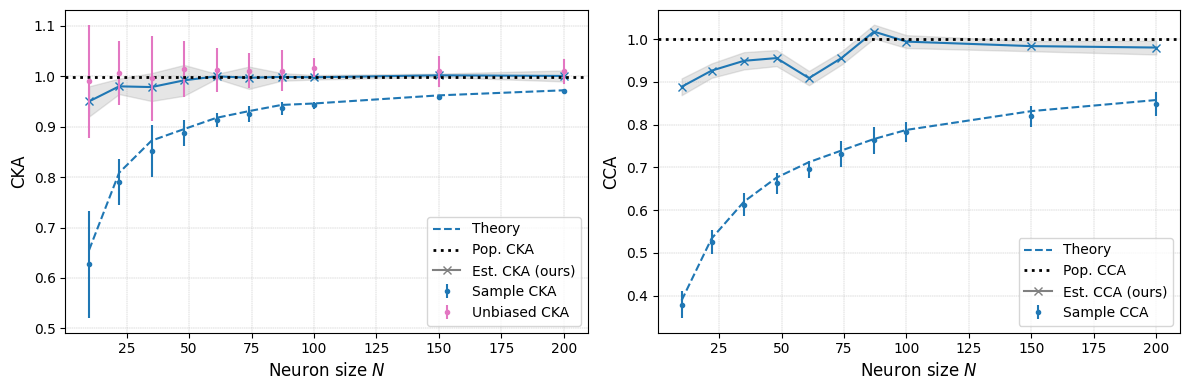

In [11]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# First subplot for CKA
ax1.errorbar(neuron_sizes, naive_mean_cka, naive_std_cka,
             fmt='.', color='C0', label='Sample CKA')
ax1.plot(neuron_sizes, predicted_cka, linestyle='--', color='C0', label='Theory')

ax1.plot(neuron_sizes, est_mean_cka, 'x-', color='C0')
ax1.fill_between(neuron_sizes,
                 est_mean_cka - est_sem_cka,
                 est_mean_cka + est_sem_cka,
                 color='gray', alpha=0.2)

ax1.errorbar(neuron_sizes, moment_cka_est_mean[:, -1], moment_cka_est_sem[:, -1],
             fmt='.', color='C6', label='Unbiased CKA')

ax1.axhline(y=true_cka, color='black', linestyle=':', linewidth=2, label='Pop. CKA')
ax1.plot([], 'x-', c='gray', label='Est. CKA (ours)')
ax1.set_xlabel(r"Neuron size $N$", fontsize=12)
ax1.set_ylabel(r"CKA", fontsize=12)
ax1.grid(True, which='both', linestyle='--', linewidth=0.3)
# ax1.set_xlim([neuron_sizes[0]-1, neuron_sizes[-1]])
ax1.legend(loc='lower right', fontsize=10)

# Second subplot for CCA
ax2.errorbar(neuron_sizes, naive_mean_cca, naive_std_cca, fmt='.', color='C0', label='Sample CCA')
ax2.plot(neuron_sizes, predicted_cca, linestyle='--', color='C0', label='Theory')

ax2.plot(neuron_sizes, est_mean_cca, 'x-', color='C0')
ax2.fill_between(neuron_sizes,
                 est_mean_cca - est_sem_cca,
                 est_mean_cca + est_sem_cca,
                 color='gray', alpha=0.2)

ax2.axhline(y=true_cca, color='black', linestyle=':', linewidth=2, label='Pop. CCA')
ax2.plot([], 'x-', c='gray', label='Est. CCA (ours)')
ax2.set_xlabel(r"Neuron size $N$", fontsize=12)
ax2.set_ylabel(r"CCA", fontsize=12)
ax2.grid(True, which='both', linestyle='--', linewidth=0.3)
# ax2.set_xlim([neuron_sizes[0]-1, neuron_sizes[-1]])
ax2.legend(loc='lower right', fontsize=10)

plt.tight_layout()
# plt.savefig('figures/cka_cca_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

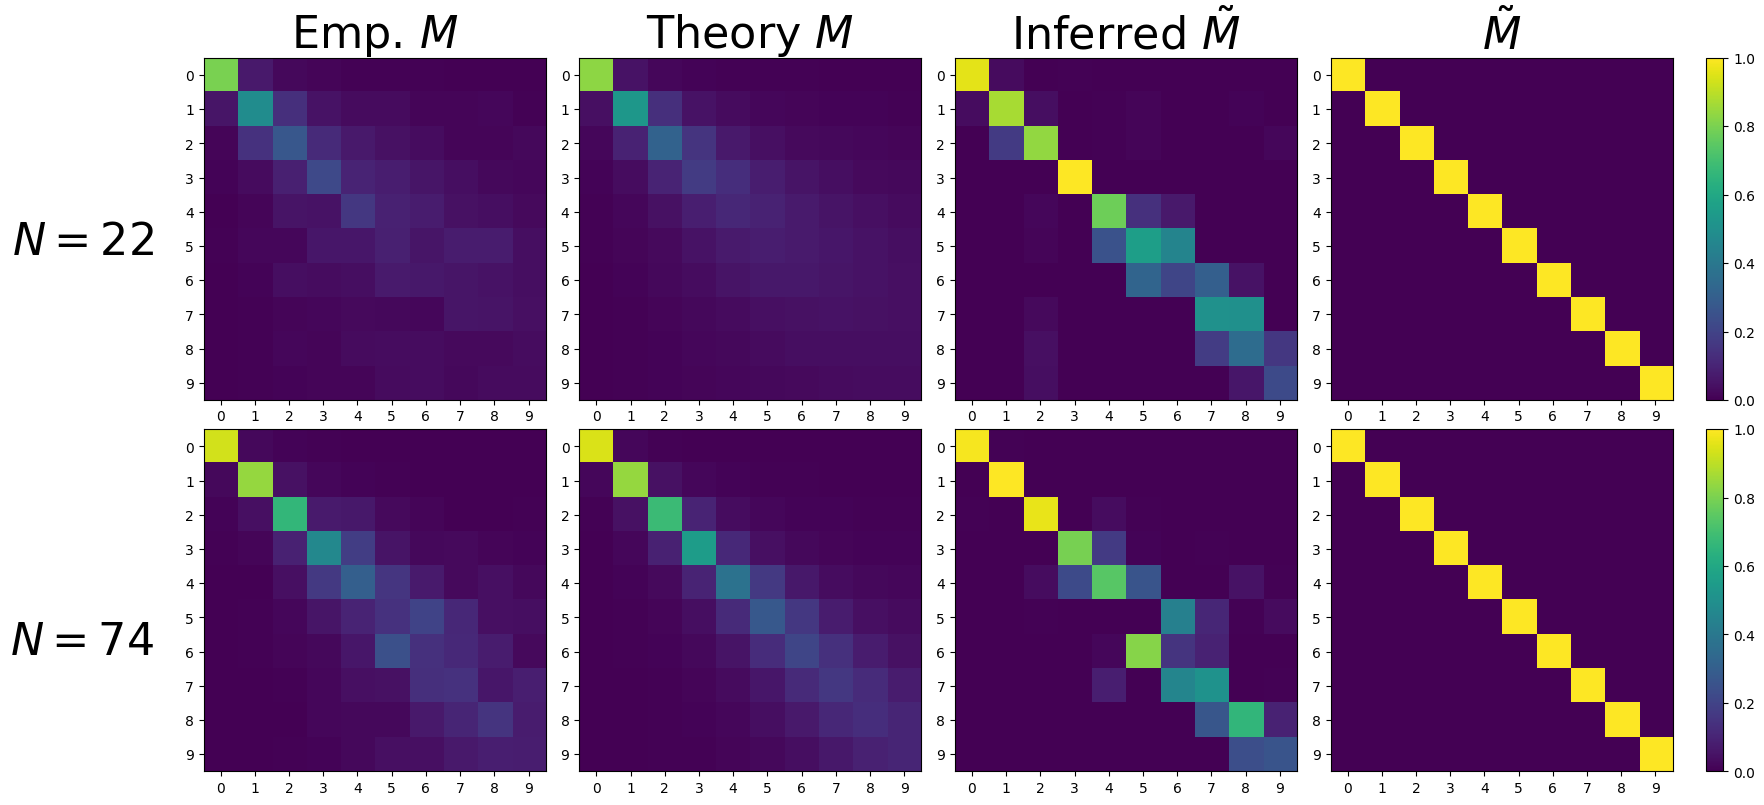

In [12]:
# Create one figure with two rows
fig = plt.figure(figsize=(16, 8))
gs = plt.GridSpec(2, 5, width_ratios=[1, 1, 1, 1, 0.05], height_ratios=[1, 1])

titles = ['Emp. $M$', 'Theory $M$', 'Inferred $\\tilde{M}$', '$\\tilde{M}$']
matrices_all = []

selected_N = [22, 74]

# First collect all matrices and find global min/max
for N in selected_N:
    i = np.where(np.array(neuron_sizes) == N)[0][0]

    M_avg = np.array(results['M_emp_mean'][i])[:10, :10]
    M_pred = np.array(results['M_pred_final'][i])[:10, :10]
    M_tilde_pred = np.array(results['M_tilde_pred_final'][i])[:10, :10]
    M_tilde = np.array(results['M_tilde'][i])[:10, :10]

    matrices = [M_avg, M_pred, M_tilde_pred, M_tilde]
    matrices_all.append(matrices)

# Find global min/max across all matrices
all_matrices = [m for row in matrices_all for sublist in row for m in [sublist]]
vmin = min(m.min() for m in all_matrices)
vmax = max(m.max() for m in all_matrices)

# Plot each row
for row, (N, matrices) in enumerate(zip(selected_N, matrices_all)):
    # Add N value on the left
    plt.figtext(-0.01, 0.7-row*0.5, f'$N={N}$', fontsize=32, ha='right', va='center')

    for col, (matrix, title) in enumerate(zip(matrices, titles)):
        ax = plt.subplot(gs[row, col])
        im = ax.imshow(matrix, cmap='viridis', vmin=vmin, vmax=vmax)
        if row == 0:  # Only show titles on top row
            ax.set_title(title, fontsize=32)
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))

    # Add colorbar for each row
    cax = plt.subplot(gs[row, -1])
    plt.colorbar(im, cax=cax)

plt.tight_layout()
# plt.savefig(os.path.join(save_path, 'M_tilde_M_comparison.pdf'), dpi=300, bbox_inches='tight')
plt.show()